# Increasing Dp as a function of time during the event: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from pathlib import Path

plt.rcParams["font.family"] = "monospace"


In [ ]:
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_dir = project_root / "Analysis"
plots_outpath = project_root / "Plots"


def save_plot(fig, filepath, dpi=300):
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches="tight", dpi=dpi)
    print(f"Saved: {filepath}")


In [3]:
do_not_include = ['2022-06-25', '2022-08-15', '2023-05-26', '2023-06-06', '2023-07-07', '2023-09-19', '2024-05-04', '2024-05-15', 
'2024-05-20', '2024-06-06', '2024-06-30', '2024-07-08', '2024-07-16', 
'2024-07-19', '2024-07-22','2024-09-13']

In [ ]:
method_name = "rate"
data_dir = analysis_dir / "selected_bonds" / "NPF_events_DMPS_NAIS"

file_path = data_dir / f"GR_{method_name}.dat"
df_GRs = pd.read_csv(file_path, index_col=0, parse_dates=True)
df_GRs["date"] = df_GRs.index
df_GRs = df_GRs.sort_values(by="date")
df_GRs = df_GRs[~df_GRs["startdate"].isin(do_not_include)]


In [ ]:
df_GRs["month"] = df_GRs.index.month
df_GRs_part1 = df_GRs[df_GRs["month"] <= 6].copy()
df_GRs_part2 = df_GRs[df_GRs["month"] > 6].copy()

part = "all"

if part == "part1":
    df_GRs = df_GRs_part1.copy()
elif part == "part2":
    df_GRs = df_GRs_part2.copy()
else:
    df_GRs = df_GRs.copy()


In [ ]:
grouped = df_GRs.groupby("startdate")
dataframes = [group for _, group in grouped]


In [8]:
hrs = np.arange(0, 100, .25)
df_concatting = pd.DataFrame(index=hrs)
list_dfs = []
for i, df in enumerate(dataframes):
    df_hr_Dp = df[['hour', 'diameters']].copy()
    df_hr_Dp = df_hr_Dp.set_index('hour')
    df_hr_Dp = df_hr_Dp.astype(float)
    list_dfs.append(df_hr_Dp)        
    df_hr_Dp = df_hr_Dp.rename(columns={'diameters':'Dp_'+str(i)})
    df_concatting = df_concatting.merge(df_hr_Dp, left_index=True, right_index=True, how='left')

In [9]:
def number_above(df_concatting, Dp = 20):
    Dp = Dp*10**(-9)
    values_above_Dp = df_concatting[df_concatting > Dp].count(axis=0)
    df_values_above_Dp = values_above_Dp.to_frame(name='above_Dp')
    df_values_above_Dp = df_values_above_Dp[df_values_above_Dp>0]
    num_above_Dp = df_values_above_Dp.count(axis=0).values[0]
    return num_above_Dp

In [10]:
df_groupby_mean_all = df_concatting.mean(axis=1)
df_groupby_median_all = df_concatting.median(axis=1)
df_groupby_25_all = df_concatting.quantile(q=0.25, axis=1)
df_groupby_75_all = df_concatting.quantile(q=0.75, axis=1)
df_groupby_count_all = df_concatting.count(axis=1)

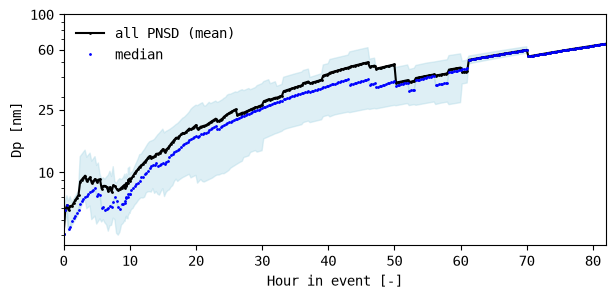

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(df_groupby_mean_all.index, df_groupby_mean_all, 'o-', ms=1, c='k', label='all PNSD (mean)')
ax.plot(df_groupby_median_all.index, df_groupby_median_all, 'o', ms=1, c='b', label='median')
ax.fill_between(df_groupby_mean_all.index, df_groupby_median_all, df_groupby_25_all, color="lightblue", alpha=0.4)
ax.fill_between(df_groupby_mean_all.index, df_groupby_75_all, df_groupby_median_all, color="lightblue", alpha=0.4)

ax.legend(loc=2, frameon=False)
ax.set_xlim(0, 82)
ax.set_yscale('log')
ax.yaxis.set_ticks((10**(-8), 25*10**(-9), 60*10**(-9), 10**(-7)))
ax.set_yticklabels(['10', '25', '60', '100'])

ax.set_ylabel('Dp [nm]')

ax.set_xlabel('Hour in event [-]')
plt.show()

In [14]:
def make_growth_plot_ax(df_concatting, label_added='pre-HOMs', color_between="lightblue", c='b', 
                        ax=None):
    
    df_groupby_mean_all = df_concatting.mean(axis=1)
    df_groupby_median_all = df_concatting.median(axis=1)
    df_groupby_25_all = df_concatting.quantile(q=0.25, axis=1)
    df_groupby_75_all = df_concatting.quantile(q=0.75, axis=1)
    df_groupby_count_all = df_concatting.count(axis=1)

    ax.plot(df_groupby_mean_all.index, df_groupby_mean_all, 'o-', ms=1, c='k', 
    label=str(label_added)+' (mean)')
    ax.plot(df_groupby_median_all.index, df_groupby_median_all, 'o', ms=1, c=c, label='median')
    ax.fill_between(df_groupby_mean_all.index, df_groupby_median_all, df_groupby_25_all, 
                    color=color_between, alpha=0.4)
    ax.fill_between(df_groupby_mean_all.index, df_groupby_75_all, df_groupby_median_all, 
                    color=color_between, alpha=0.4)
    
    ax.legend(loc=2, frameon=False)
    ax.set_xlim(0, 82)
    ax.set_yticks([10**(-8), 2.5*10**(-8), 5*10**(-8), 7.5*10**(-8), 10**(-7)], [10, 25, 50, 75, 100])
    ax.set_ylabel('Dp [nm]')
    ax.set_yscale('log')
    ax.set_xlabel('Hour in event [-]')
    return ax

In [15]:
def produce_ax(df_concatting, label_added='pre-HOMs', color_between="lightblue", c='b', ax=None):
    df_groupby_mean_all = df_concatting.mean(axis=1)
    df_groupby_median_all = df_concatting.median(axis=1)
    df_groupby_25_all = df_concatting.quantile(q=0.25, axis=1)
    df_groupby_75_all = df_concatting.quantile(q=0.75, axis=1)
    df_groupby_count_all = df_concatting.count(axis=1)

    ax.plot(df_groupby_mean_all.index, df_groupby_mean_all, 'o-', ms=1, c='k',)
    ax.plot(df_groupby_median_all.index, df_groupby_median_all, 'o-', ms=1, c=c,)
    ax.fill_between(df_groupby_mean_all.index, df_groupby_median_all, df_groupby_25_all, 
    color=color_between, alpha=0.4)
    ax.fill_between(df_groupby_mean_all.index, df_groupby_75_all, df_groupby_median_all, 
    color=color_between, alpha=0.4)
    
    ax.set_xlim(0, 82)
    ax.set_yticks([10**(-8), 2.5*10**(-8), 5*10**(-8), 7.5*10**(-8), 10**(-7)], [10, 25, 50, 75, 100])
    ax.set_ylabel('Dp [nm]', fontsize=15)
    ax.set_yscale('log')
    ax.set_xlabel('Hour in event [-]', fontsize=15)
    return ax

In [ ]:
for Dp in (10, 20):
    count = df_groupby_count_all[df_groupby_count_all.index == Dp].values[0]
    print(f"At {Dp} h: {count} event points")


59
66
66


In [17]:
Dp=20
count = number_above(df_concatting, Dp=Dp)

In [18]:
def get_df_count(df_concatting):
    Dps = np.arange(2.5, 100, .5)
    dict_Dps_counts = {}
    for Dp in Dps:
        count = number_above(df_concatting, Dp=Dp)
        dict_Dps_counts[Dp] = count
    df_Dp_count = pd.DataFrame(dict_Dps_counts.items(), columns=['Dp', 'count'])
    return df_Dp_count

In [19]:
df_Dp_count = get_df_count(df_concatting)

In [20]:
def Dp_changes_hr_fig(df_Dp_count):
    fig = plt.figure(figsize=(8, 5))  # Adjust the figsize as needed
    gs = GridSpec(5, 5, figure=fig)

    ax3 = fig.add_subplot(gs[1:4, 4])
    ax3.plot(df_Dp_count['count'], df_Dp_count['Dp']/10**(9), c='b') #df_Dp_count['count'].values[0]
    ax3.set_yscale('log')

    ax2 = fig.add_subplot(gs[1:4, 0:4])
    produce_ax(df_concatting, ax=ax2)
    ax2.axhspan(25*10**(-9), float(df_Dp_count['Dp'].max())*10**(-9), alpha=.2)
    ax2.text(1, .75*10**(-7), s='a)', fontsize=15)
    #ax2.legend(loc=4, frameon=False, fontsize=15)
    ax2.set_ylim(2*10**(-9), 10**(-7))

    Dp=25
    count = number_above(df_concatting, Dp=Dp)
    ax3.text(150, 20*(10)**(-9), str(count)+' (>25nm)', fontsize=15, rotation=90)
    ax3.axhline(y=Dp*(10)**(-9), ls=':', xmin=0, xmax=count) #, ymax=(Dp)*10**(-9))
    ax3.axvline(x=count, ymin=0, ls=':') #, ymax=(Dp)*10**(-9))
    ax3.set_xlabel('Number of events [-]', fontsize=15)
    ax3.text(6, .75*10**(-7), s='b)', fontsize=15)
    ax3.axhspan(25*10**(-9), float(df_Dp_count['Dp'].max())*10**(-9), alpha=.2)
    # x_max = 65
    ax3.set_ylim(2*10**(-9), 10**(-7))
    ax2.yaxis.set_ticks((10**(-8), 25*10**(-9), 60*10**(-9), 10**(-7)))
    ax3.yaxis.set_ticks((10**(-8), 25*10**(-9), 60*10**(-9), 10**(-7)))
    ax2.set_yticklabels(['10', '25', '60', '100'])
    ax3.set_yticklabels(['10', '25', '60', '100'])

    for ax in [ax2, ax3]:
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.tick_params(axis='both', which='minor', labelsize=15)

    plt.tight_layout()
    plt.show()
    return fig

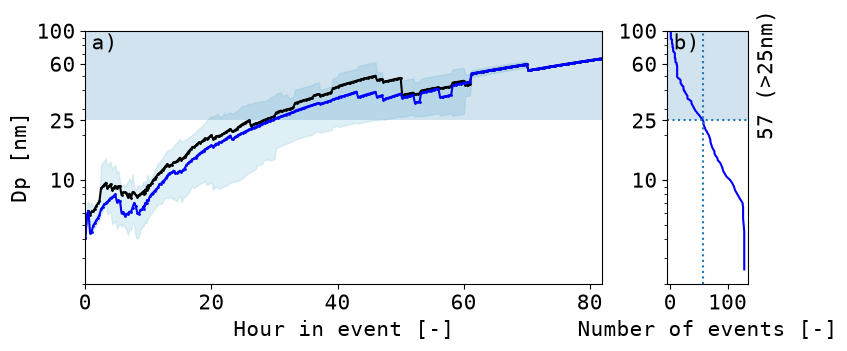

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_12.jpeg


In [21]:
fig = Dp_changes_hr_fig(df_Dp_count)
output_figure = plots_outpath / 'Figure_12.jpeg'
save_plot(fig, output_figure)

In [ ]:
for Dp in (0, 25, 60, 70, 80):
    print(f"Dp > {Dp} nm: {number_above(df_concatting, Dp=Dp)}")


129
57
11
8
4
